# Embedding

## Why Embedding?
As we know, machines can't handle text, it can only handle numbers. But how to convert a word to numbers?

The most naive approach would be to take a list of all the words in your text and attribute a number to all of them. It will work but you can imagine that some problems will appear:
* How do you handle unknown words? 
* If your text contains `doctor`, `nurse`, and `candy`. `doctor` and `nurse` have a strong similarity but `candy` doesn't. How can we make the machine understand that? With our naive technique, `doctor` could have the number `5` associated to it and nurse the number `98767`.

Of course, a lot of people already spent some time with those problems. the solution that came out of it is "Embedding". 

## What is embeddings?

An embedding is a **VECTOR** which represents a word or a document.

A vector will be attributed to each token. Each vector will contain multiple dimensions (usually tens or hundreds of dimensions).

```
[...] associate with each word in the vocabulary a distributed word feature vector [...] The feature vector represents different aspects of the word: each word is associated with a point in a vector space. The number of features [...] is much smaller than the size of the vocabulary.
```
- [A Neural Probabilistic Language Model](https://www.jmlr.org/papers/volume3/bengio03a/bengio03a.pdf), 2003.

Long story short, embeddings convert words into vectors in a way that allows the machine to understand the similarity betweens them.

Each embedding library has it's own way of classifying words, it will regroup words into big categories. Each word will get a score for each category.

To take a simple example the word `mother` could be classified like that:

|        | female | family | human | animal|
|--------|--------|---------|-------|-------|
| mother | 0.9    | 0.9.    | 0.7   | 0.1   |

**Explanations:** Mother has a strong similarity with female, family and human but it has a low similarity with animal.

**Disclaimer:** Those numbers and categories are totally arbitrary and are only here to show an example.

Here is another example with more complete datas:

![embedding](https://miro.medium.com/max/2598/1*sAJdxEsDjsPMioHyzlN3_A.png)

## Should I do it by hand?

You could, but if some people already did the job for you and spent a lot of time to optimize it, why not use it?

## What to use?

There are a lot of libraries out there for embeddings. Which one is the best? Once again, *it depends*. The results will change depending on the text you are using, the information you want to extract, the model you use,...

Choosing the "best" embedding model will be part of the hyper-optimization that you can do at the end of a project.

If you want understand embeddings more in depth, [follow this link](http://jalammar.github.io/illustrated-word2vec/) or watch this [video](https://www.youtube.com/watch?v=gQddtTdmG_8).

Here are some of the best libraries:

* [Gensim](https://pypi.org/project/gensim/)
* [Word2Vec](https://www.tensorflow.org/tutorials/text/word2vec)

This next bit of code loads a model for practice

In [1]:
import os
import gensim.downloader as api
from gensim.models import KeyedVectors
import math
import numpy as np

# Path where you want to store/load the model
model_path = "glove-wiki-gigaword-300.kv"

# Load model from disk if exists, else download and save it
if os.path.exists(model_path):
    print("Loading model from local file...")
    model = KeyedVectors.load("data/"+model_path)
else:
    print("Downloading model...")
    model = api.load(model_path[:-3])
    model.save("data/"+model_path)
    print("Model downloaded and saved.")

Model downloaded and saved.


## Practice time!

Enough reading, let's practice a bit. On this sentence:

In [2]:
sentence = "I love learning"

What do the word vectors look like? What is their size? What is their [magnitude](https://numpy.org/doc/2.1/reference/generated/numpy.linalg.norm.html)?

In [3]:
sentence = "I love learning"
words = sentence.split()
print(f"Words: {words}")

for word in words:
    if word.lower() in model :
        vector = model[word.lower()]
        print(f"\nWord: '{word}'")
        print(f"Vector shape: {vector.shape}")
        print(f"Vector size: {len(vector)}")
        print(f"Vector magnitude: {np.linalg.norm(vector):.4f}")
        print(f"First 10 dimensions: {vector[:10]}")
    else:
        print(f"Word '{word}' not found in model vocabulary")

Words: ['I', 'love', 'learning']

Word: 'I'
Vector shape: (300,)
Vector size: 300
Vector magnitude: 6.9177
First 10 dimensions: [-0.13292   0.16985  -0.1436   -0.088722  0.07951  -0.14212  -0.024209
 -0.26291  -0.074814 -2.36    ]

Word: 'love'
Vector shape: (300,)
Vector size: 300
Vector magnitude: 6.1361
First 10 dimensions: [-0.45205  -0.33122  -0.063607  0.028325 -0.21372   0.16839  -0.017186
  0.047309 -0.052355 -0.98706 ]

Word: 'learning'
Vector shape: (300,)
Vector size: 300
Vector magnitude: 5.9555
First 10 dimensions: [-0.38732   -0.32467    0.22053   -0.12059   -0.14239    0.0017644
  0.047267  -0.10137    0.01616   -1.4371   ]


In [4]:
# import os

# # Supprimer le fichier corrompu
# if os.path.exists("data/glove-wiki-gigaword-300.kv"):
#     os.remove("data/glove-wiki-gigaword-300.kv")
#     print("Fichier corrompu supprimé")

# # Puis relancer votre cellule de chargement du modèle

## Maths on text

Since the words are embedded into vectors we can now apply mathematical methods on them.

### Average vector

For example we could build the average vector for a text by using NumPy! This is a straightforward way to build one single representation for a text.

- Apply a gensim model on the text
- Get all word vectors into a list
- Compute and display the average vector of the list
- Get it's representation using the gensim most_similar method

In [5]:
text = "I want to be a famous data scientist"

words = text.split()
print(f"Words: {words}")

all_word_vectors = []
# Get all word vectors into a list
for word in words:
    if word.lower() in model :
        vector = model[word.lower()]

        # print(f"\nWord: '{word}'")
        # print(f"Vector shape: {vector.shape}")
        # print(f"Vector size: {len(vector)}")
        # print(f"Vector magnitude: {np.linalg.norm(vector):.4f}")
        # print(f"First 10 dimensions: {vector[:10]}")

        all_word_vectors.append(vector)

    else:
        print(f"Word '{word}' not found in model vocabulary")

print(all_word_vectors)


Words: ['I', 'want', 'to', 'be', 'a', 'famous', 'data', 'scientist']
[array([-1.3292e-01,  1.6985e-01, -1.4360e-01, -8.8722e-02,  7.9510e-02,
       -1.4212e-01, -2.4209e-02, -2.6291e-01, -7.4814e-02, -2.3600e+00,
        3.4830e-01, -9.1722e-02, -5.3906e-02,  3.0418e-01, -1.3286e-01,
        5.0341e-03, -1.5056e-01,  2.3562e-03,  6.8321e-02,  3.4246e-01,
        3.9891e-01,  5.8813e-01,  6.0618e-02, -1.9871e-01, -4.0465e-01,
       -1.0706e-01, -5.9312e-03, -6.4842e-01,  1.9080e-01, -1.7630e-01,
        9.2407e-02,  3.8685e-01, -3.1085e-01, -3.2574e-01, -1.6823e+00,
        2.5336e-01, -2.4647e-01, -1.0874e-01,  7.6402e-03,  3.3880e-01,
       -5.9736e-02, -8.5940e-01, -8.0964e-02, -2.2981e-01,  1.7709e-01,
        8.2094e-02,  7.4416e-01,  3.6873e-01,  1.3740e-01,  2.9408e-01,
        1.0647e-01, -1.3246e-01,  1.2134e-01, -1.4273e-01, -5.3270e-01,
        6.4936e-01,  4.9657e-01,  3.0029e-01,  6.7226e-01,  1.8005e-01,
        8.8050e-01,  3.8144e-02, -8.7140e-02,  7.6400e-01, -1.2107

In [6]:
#Compute and display the average vector

average_vector_mean = sum(all_word_vectors) / len(all_word_vectors)
print(average_vector_mean)



[-6.72467574e-02  1.12447746e-01 -7.71599859e-02 -1.69428512e-01
 -5.58186248e-02 -9.41490084e-02 -5.27175106e-02 -1.63590372e-01
  1.71046898e-01 -1.79302382e+00  1.76756769e-01 -2.72012115e-01
  1.42969117e-01  7.32323825e-02  4.17656302e-02  1.89646140e-01
 -8.18032548e-02 -2.79211383e-02  7.30096251e-02 -3.21437493e-02
 -6.62687570e-02  1.78439721e-01  2.54457235e-01  2.77096242e-01
 -2.80990869e-01 -8.41237605e-03  6.61918521e-02 -1.09376237e-01
  4.87642437e-02  3.15013751e-02 -2.06287671e-03  2.67908037e-01
 -3.09515625e-01 -9.38455015e-02 -8.12166214e-01  1.82940513e-01
 -5.60493767e-02  1.22733869e-01 -3.00024766e-02  1.23137251e-01
 -2.47410014e-02 -1.69102743e-01  3.15025002e-02  1.52458251e-01
 -1.54302120e-01  8.37732479e-02  1.22663744e-01  9.39768776e-02
 -1.77266628e-01 -6.49045482e-02  1.00111119e-01 -2.05699265e-01
  2.79726274e-02  3.56931277e-02 -1.47227630e-01  1.55752242e-01
  3.81776243e-02  1.37220010e-01  5.79744950e-02  5.52836321e-02
 -7.84437358e-03  1.21477

In [7]:
# Represent average vector with most_similar method
rpz_average = model.most_similar(average_vector_mean)
average_vector = model.most_similar(positive=average_vector_mean, topn=5)

print(rpz_average)
print(average_vector)

# Check model quality
print(f"Model vocabulary size: {len(model)}")
print(f"Vector dimensions: {model.vector_size}")
print("Sample words in vocabulary:", list(model.index_to_key)[:20])

[('so', 0.7829076647758484), ('not', 0.7719873189926147), ('you', 0.7669453024864197), ("n't", 0.7651411294937134), ('this', 0.7642149329185486), ('what', 0.7638728022575378), ('could', 0.7617281675338745), ('if', 0.7532414793968201), ('be', 0.7527317404747009), ('want', 0.7498790621757507)]
[('so', 0.7829076647758484), ('not', 0.7719873189926147), ('you', 0.7669453024864197), ("n't", 0.7651411294937134), ('this', 0.7642149329185486)]
Model vocabulary size: 400000
Vector dimensions: 300
Sample words in vocabulary: ['the', ',', '.', 'of', 'to', 'and', 'in', 'a', '"', "'s", 'for', '-', 'that', 'on', 'is', 'was', 'said', 'with', 'he', 'as']


In [8]:
# Import necessary libraries for visualization
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Prepare data for visualization
vectors_to_plot = []
labels = []
colors = []

# 1. Add average vector (red)
vectors_to_plot.append(average_vector_mean)
labels.append("Average Vector")
colors.append('red')

# 2. Add original sentence words (blue)
original_words = ["want", "be", "famous", "data", "scientist", ]  # Skip common words like "I", "to", "a"
for word in original_words:
    if word.lower() in model:
        vectors_to_plot.append(model[word.lower()])
        labels.append(f"Original: {word}")
        colors.append('blue')

# 3. Add similar words (green) - automatically from most_similar results
similar_words = [word for word, score in rpz_average[:5]]  # Extract first 5 words
for word in similar_words:
    if word.lower() in model:
        vectors_to_plot.append(model[word.lower()])
        labels.append(f"Similar: {word}")
        colors.append('green')

print(f"Total vectors to plot: {len(vectors_to_plot)}")

Total vectors to plot: 11


In [9]:
# Apply PCA to reduce dimensions from 300D to 2D
pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(vectors_to_plot)

print(f"Original shape: {np.array(vectors_to_plot).shape}")
print(f"After PCA: {vectors_2d.shape}")
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")

Original shape: (11, 300)
After PCA: (11, 2)
Explained variance ratio: [0.32631085 0.24358697]


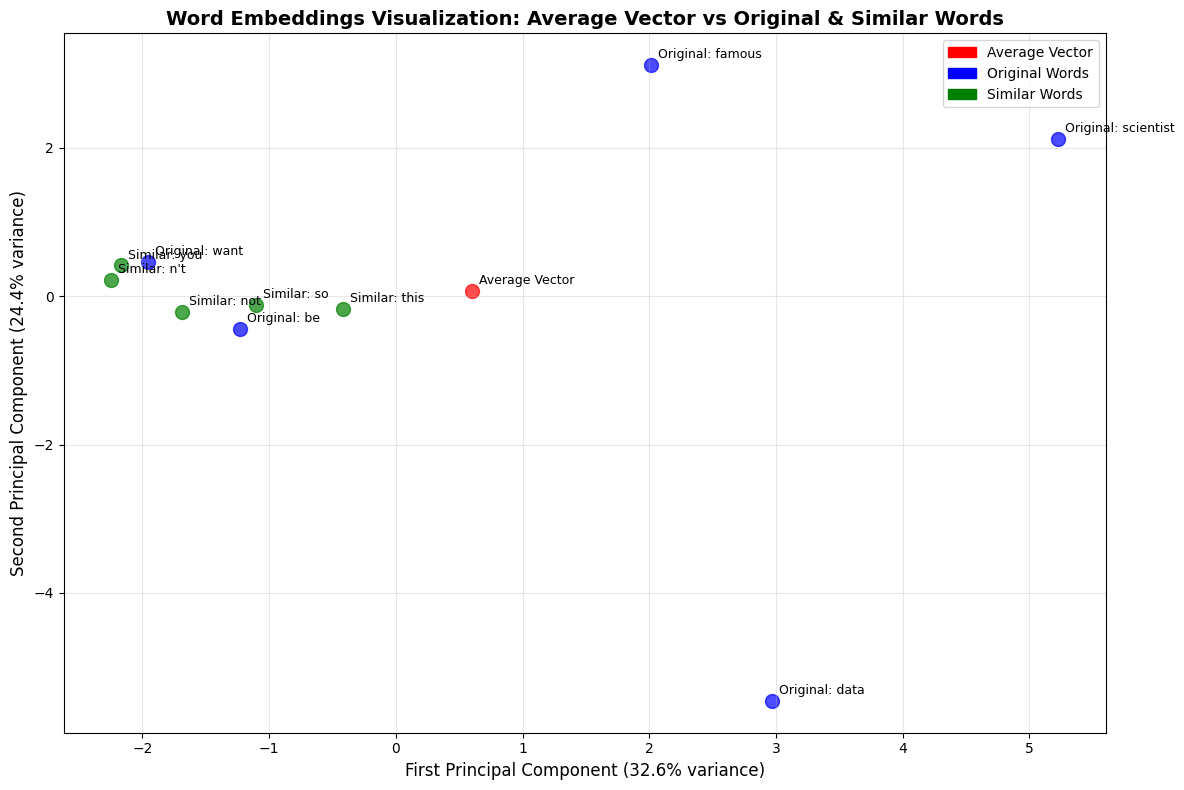

In [10]:
# Create the visualization
plt.figure(figsize=(12, 8))

# Plot each point with different colors
for i, (x, y) in enumerate(vectors_2d):
    plt.scatter(x, y, c=colors[i], s=100, alpha=0.7)
    plt.annotate(labels[i], (x, y), xytext=(5, 5), textcoords='offset points', 
                fontsize=9, ha='left')

# Customize the plot
plt.title('Word Embeddings Visualization: Average Vector vs Original & Similar Words', 
          fontsize=14, fontweight='bold')
plt.xlabel(f'First Principal Component ({pca.explained_variance_ratio_[0]:.1%} variance)', 
           fontsize=12)
plt.ylabel(f'Second Principal Component ({pca.explained_variance_ratio_[1]:.1%} variance)', 
           fontsize=12)

# Add legend
import matplotlib.patches as mpatches
red_patch = mpatches.Patch(color='red', label='Average Vector')
blue_patch = mpatches.Patch(color='blue', label='Original Words')
green_patch = mpatches.Patch(color='green', label='Similar Words')
plt.legend(handles=[red_patch, blue_patch, green_patch], loc='best')

# Add grid for better readability
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Word similarity

We can also compute the similarity between two words by using distance measures (e.g. [cosine similarity](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.pairwise.cosine_similarity.html), [euclidean distance](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.pairwise.euclidean_distances.html)...). These measures will calculate the distance between word embeddings in the vector space.

Identify what fundamental difference there is between these two metrics when it comes to assessissing similarity between vectors.

#### Let's practice!

- Compute the cosine and the euclidean distance between those 4 words in a similarity table visualizing it with matplotlib and/or seaborn
- Assess which words are the most similar and the most dissimilar

In [11]:
words = ["computer","keyboard","water","ocean"]
X = model[words] # Get vectors for the words

# cosine similarity
from sklearn.metrics.pairwise import cosine_similarity
print(cosine_similarity(X))

# euclidean distance
from sklearn.metrics.pairwise import euclidean_distances
print(euclidean_distances(X,X))

[[1.0000001  0.44146118 0.12432652 0.14268494]
 [0.44146118 0.99999994 0.05421676 0.07489929]
 [0.12432652 0.05421676 1.0000002  0.4769016 ]
 [0.14268494 0.07489929 0.4769016  1.        ]]
[[0.        7.5356393 9.546108  9.045488 ]
 [7.5356393 0.        9.84485   9.315822 ]
 [9.546108  9.84485   0.        7.107027 ]
 [9.045488  9.315822  7.107027  0.       ]]


_Je ne comprends pas pourquoi les nombres sont totalement différents d'un tableau à l'autre alors qu'on est censé calculer la distance entre deux mots_

C'est une excellente question et une source de confusion fréquente quand on découvre ces deux mesures ! Tu as raison de pointer cette différence.

## Le cœur du problème : "Distance" a plusieurs sens

Imagine que tu veuilles mesurer la "proximité" entre deux villes :
*   Tu pourrais mesurer la **distance à vol d'oiseau** (comme un trait droit sur une carte).
*   Tu pourrais mesurer le **temps de trajet en voiture** (qui dépend des routes, des limitations de vitesse, etc.).

Ces deux mesures te donneraient des chiffres différents, mais les deux parlent de "proximité". C'est pareil pour la similarité cosinus et la distance euclidienne !

## Réfléchissons aux deux mesures :

### 1. Similarité Cosinus : L'Angle compte !

*   **Qu'est-ce qu'elle mesure ?** Elle regarde l'**angle** entre les deux vecteurs de mots.
    *   Si les vecteurs pointent dans la **même direction** (angle petit), la similarité est proche de 1 (très similaires).
    *   Si les vecteurs sont **perpendiculaires** (angle de 90 degrés), la similarité est proche de 0 (pas similaires).
    *   Si les vecteurs pointent dans des **directions opposées**, la similarité est proche de -1 (très dissimilaires).
*   **Sensibilité à la magnitude (longueur du vecteur) ?** Non. Peu importe si un vecteur est "long" ou "court", seul l'angle compte.
*   **Plage de valeurs typique :** Souvent entre 0 et 1 pour les embeddings de mots (car ils sont généralement dans le même "quadrant" de l'espace), où 1 est le maximum de similarité.

### 2. Distance Euclidienne : La Ligne Droite compte !

*   **Qu'est-ce qu'elle mesure ?** C'est la **distance "géométrique" directe** entre les pointes des deux vecteurs dans l'espace à 300 dimensions. C'est comme prendre une règle et mesurer la distance entre les deux points.
*   **Sensibilité à la magnitude ?** Oui. Si deux vecteurs pointent dans la même direction mais l'un est beaucoup plus long que l'autre, la distance euclidienne sera grande.
*   **Plage de valeurs typique :** De 0 à l'infini.
    *   0 signifie que les vecteurs sont identiques (au même endroit).
    *   Plus la valeur est grande, plus les mots sont "éloignés" et donc moins similaires.

## Analysons tes tableaux :

### Tableau de Similarité Cosinus :



<code>
[[1.         0.44146118 0.12432652 0.14268494]  <- computer vs (computer, keyboard, water, ocean)

[0.44146118 1.         0.05421676 0.07489929]  <- keyboard vs (...)

[0.12432652 0.05421676 1.         0.4769016 ]  <- water vs (...)

[0.14268494 0.07489929 0.4769016  1.        ]] <- ocean vs (...)
</code>

 


*   **Diagonale à 1** : Un mot est parfaitement similaire à lui-même (angle de 0 degré).
*   **"computer" et "keyboard" (0.44)** : Assez similaires en termes d'orientation.
*   **"water" et "ocean" (0.47)** : Assez similaires en termes d'orientation.
*   **"keyboard" et "water" (0.05)** : Très peu similaires en termes d'orientation (presque perpendiculaires).

### Tableau de Distance Euclidienne :
<code>
[[0.        7.5356393 9.546108  9.045488 ]

[7.5356393 0.        9.84485   9.315822 ]

[9.546108  9.84485   0.        7.107027 ]

[9.045488  9.315822  7.107027  0.       ]]
</code>

*   **Diagonale à 0** : La distance d'un mot à lui-même est nulle.
*   **"computer" et "keyboard" (7.53)** : Une certaine distance.
*   **"water" et "ocean" (7.10)** : Une certaine distance, comparable à computer/keyboard.
*   **"keyboard" et "water" (9.84)** : Une distance plus grande, indiquant qu'ils sont plus éloignés dans l'espace.

## Conclusion :

Les deux mesures te donnent des informations sur la "proximité" des mots, mais elles le font de manière différente :
*   **Similarité Cosinus** : Est-ce qu'ils "pointent" dans la même direction sémantique ? (Bon pour le sens)
*   **Distance Euclidienne** : Sont-ils proches géométriquement dans l'espace des embeddings ? (Peut être affecté par la fréquence des mots ou d'autres facteurs qui influencent la magnitude du vecteur)

C'est pourquoi les chiffres sont différents. Ils ne mesurent pas la même *chose* de la même *manière*.

Est-ce que cette explication t'aide à mieux comprendre pourquoi les valeurs diffèrent ? Laquelle des deux mesures te semble la plus intuitive pour évaluer la "similarité de sens" entre des mots ?

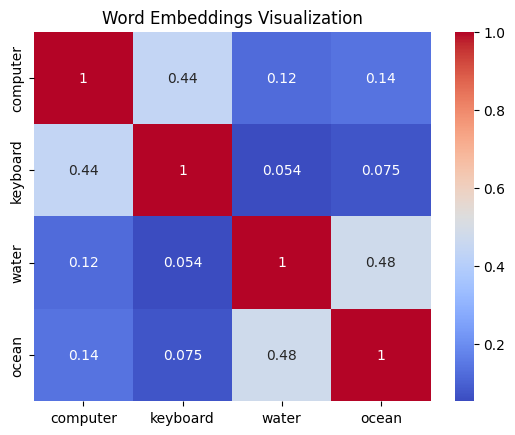

In [12]:
# visualization
import seaborn as sns
import matplotlib.pyplot as plt

#cosine similarity visualization
cosine_sim_matrix = cosine_similarity(X)
sns.heatmap(cosine_sim_matrix, annot=True, xticklabels=words, yticklabels=words, cmap='coolwarm')


euclidean_dist_matrix = euclidean_distances(X, X)
plt.title('Word Embeddings Visualization')
plt.show()


## Combining things together

This next bit of code uses the gensim library to allow you to perform arithmetic operations on vectors. Things you may want to try:

Silly additions:
 - man + hair

Checking for some more abstractions:
 - hair - woman + man
 - mice - home + city
 - children - child + goose
 - paris - france + belgium

Bonus points if you can make a function which takes any form of addition and substraction calculations on word vectors.

In [19]:
equals=model.most_similar(positive=['king', 'woman'], negative=['man'])[0][0]
print(f"'king' - 'man' + 'woman' = {equals}'")

equals=model.most_similar(positive=['liège', 'belgium'], negative=['beer'])[0][0]
print(f"'Liège' - 'beer' + 'Belgium' = {equals}'")

'king' - 'man' + 'woman' = queen'
'Liège' - 'beer' + 'Belgium' = ghent'


When you play with these examples (or others). You quickly notice both the powerful levels of abstraction and the gaping limitations.

## More resources
* [Why do we use word embeddings in NLP?](https://towardsdatascience.com/why-do-we-use-embeddings-in-nlp-2f20e1b632d2)
* [More details on what word embeddings are exactly?](https://www.analyticsvidhya.com/blog/2017/06/word-embeddings-count-word2veec/)